In [1]:
pip install pandas matplotlib seaborn plotly fhirclient scikit-learn networkx nbformat

In [2]:
import pandas as pd

# Example: Load patient, claims, provider CSV files
# patients_df = pd.read_csv('D:/Workspace/data/output_ie_galway_1k/csv/patients.csv')
# claims_df = pd.read_csv('D:/Workspace/data/output_ie_galway_1k/csv/claims.csv')
# transactions_df = pd.read_csv('D:/Workspace/data/output_ie_galway_1k/csv/claims_transactions.csv')
# providers_df = pd.read_csv('D:/Workspace/data/output_ie_galway_1k/csv/providers.csv')
patients_df = pd.read_csv('D:/Workspace/data/output_ie_dublin_5k/csv/patients.csv')
claims_df = pd.read_csv('D:/Workspace/data/output_ie_dublin_5k/csv/claims.csv')
transactions_df = pd.read_csv('D:/Workspace/data/output_ie_dublin_5k/csv/claims_transactions.csv')
providers_df = pd.read_csv('D:/Workspace/data/output_ie_dublin_5k/csv/providers.csv')
# Add other datasets as needed

print(patients_df.columns)
print(claims_df.columns)
print(transactions_df.columns)
print(providers_df.columns)

C:\Users\nithinmohan\AppData\Local\Temp\ipykernel_25280\4225257987.py:10: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  transactions_df = pd.read_csv('D:/Workspace/data/output_ie_dublin_5k/csv/claims_transactions.csv')


Index(['Id', 'BIRTHDATE', 'DEATHDATE', 'SSN', 'DRIVERS', 'PASSPORT', 'PREFIX',
       'FIRST', 'MIDDLE', 'LAST', 'SUFFIX', 'MAIDEN', 'MARITAL', 'RACE',
       'ETHNICITY', 'GENDER', 'BIRTHPLACE', 'ADDRESS', 'CITY', 'STATE',
       'COUNTY', 'FIPS', 'ZIP', 'LAT', 'LON', 'HEALTHCARE_EXPENSES',
       'HEALTHCARE_COVERAGE', 'INCOME'],
      dtype='object')
Index(['Id', 'PATIENTID', 'PROVIDERID', 'PRIMARYPATIENTINSURANCEID',
       'SECONDARYPATIENTINSURANCEID', 'DEPARTMENTID', 'PATIENTDEPARTMENTID',
       'DIAGNOSIS1', 'DIAGNOSIS2', 'DIAGNOSIS3', 'DIAGNOSIS4', 'DIAGNOSIS5',
       'DIAGNOSIS6', 'DIAGNOSIS7', 'DIAGNOSIS8', 'REFERRINGPROVIDERID',
       'APPOINTMENTID', 'CURRENTILLNESSDATE', 'SERVICEDATE',
       'SUPERVISINGPROVIDERID', 'STATUS1', 'STATUS2', 'STATUSP',
       'OUTSTANDING1', 'OUTSTANDING2', 'OUTSTANDINGP', 'LASTBILLEDDATE1',
       'LASTBILLEDDATE2', 'LASTBILLEDDATEP', 'HEALTHCARECLAIMTYPEID1',
       'HEALTHCARECLAIMTYPEID2'],
      dtype='object')
Index(['ID', 'CLAIMID'

In [3]:
#preprocessing

# Convert date columns to datetime
claims_df['SERVICEDATE'] = pd.to_datetime(claims_df['SERVICEDATE'], errors='coerce')
claims_df['LASTBILLEDDATE1'] = pd.to_datetime(claims_df['LASTBILLEDDATE1'], errors='coerce')
transactions_df['FROMDATE'] = pd.to_datetime(transactions_df['FROMDATE'], errors='coerce')
transactions_df['TODATE'] = pd.to_datetime(transactions_df['TODATE'], errors='coerce')

# Handle missing values
claims_df.fillna({'AMOUNT': 0}, inplace=True)
transactions_df.fillna({'AMOUNT': 0}, inplace=True)

print("Claims DataFrame columns:", claims_df.columns)
print("Transactions DataFrame columns:", transactions_df.columns)

Claims DataFrame columns: Index(['Id', 'PATIENTID', 'PROVIDERID', 'PRIMARYPATIENTINSURANCEID',
       'SECONDARYPATIENTINSURANCEID', 'DEPARTMENTID', 'PATIENTDEPARTMENTID',
       'DIAGNOSIS1', 'DIAGNOSIS2', 'DIAGNOSIS3', 'DIAGNOSIS4', 'DIAGNOSIS5',
       'DIAGNOSIS6', 'DIAGNOSIS7', 'DIAGNOSIS8', 'REFERRINGPROVIDERID',
       'APPOINTMENTID', 'CURRENTILLNESSDATE', 'SERVICEDATE',
       'SUPERVISINGPROVIDERID', 'STATUS1', 'STATUS2', 'STATUSP',
       'OUTSTANDING1', 'OUTSTANDING2', 'OUTSTANDINGP', 'LASTBILLEDDATE1',
       'LASTBILLEDDATE2', 'LASTBILLEDDATEP', 'HEALTHCARECLAIMTYPEID1',
       'HEALTHCARECLAIMTYPEID2'],
      dtype='object')
Transactions DataFrame columns: Index(['ID', 'CLAIMID', 'CHARGEID', 'PATIENTID', 'TYPE', 'AMOUNT', 'METHOD',
       'FROMDATE', 'TODATE', 'PLACEOFSERVICE', 'PROCEDURECODE', 'MODIFIER1',
       'MODIFIER2', 'DIAGNOSISREF1', 'DIAGNOSISREF2', 'DIAGNOSISREF3',
       'DIAGNOSISREF4', 'UNITS', 'DEPARTMENTID', 'NOTES', 'UNITAMOUNT',
       'TRANSFEROUTID',

In [4]:
# Cleansing

transactions_df.rename(columns={'ID': 'TRANSACTIONID'}, inplace=True)
transactions_df.rename(columns={'PROVIDERID': 'TRANS_PROVIDERID'}, inplace=True)
transactions_df.rename(columns={'PATIENTID': 'TRANS_PATIENTID'}, inplace=True)
transactions_df.rename(columns={'APPOINTMENTID': 'TRANS_APPOINTMENTID'}, inplace=True)
print(claims_df.columns.tolist())
print(transactions_df.columns.tolist())


['Id', 'PATIENTID', 'PROVIDERID', 'PRIMARYPATIENTINSURANCEID', 'SECONDARYPATIENTINSURANCEID', 'DEPARTMENTID', 'PATIENTDEPARTMENTID', 'DIAGNOSIS1', 'DIAGNOSIS2', 'DIAGNOSIS3', 'DIAGNOSIS4', 'DIAGNOSIS5', 'DIAGNOSIS6', 'DIAGNOSIS7', 'DIAGNOSIS8', 'REFERRINGPROVIDERID', 'APPOINTMENTID', 'CURRENTILLNESSDATE', 'SERVICEDATE', 'SUPERVISINGPROVIDERID', 'STATUS1', 'STATUS2', 'STATUSP', 'OUTSTANDING1', 'OUTSTANDING2', 'OUTSTANDINGP', 'LASTBILLEDDATE1', 'LASTBILLEDDATE2', 'LASTBILLEDDATEP', 'HEALTHCARECLAIMTYPEID1', 'HEALTHCARECLAIMTYPEID2']
['TRANSACTIONID', 'CLAIMID', 'CHARGEID', 'TRANS_PATIENTID', 'TYPE', 'AMOUNT', 'METHOD', 'FROMDATE', 'TODATE', 'PLACEOFSERVICE', 'PROCEDURECODE', 'MODIFIER1', 'MODIFIER2', 'DIAGNOSISREF1', 'DIAGNOSISREF2', 'DIAGNOSISREF3', 'DIAGNOSISREF4', 'UNITS', 'DEPARTMENTID', 'NOTES', 'UNITAMOUNT', 'TRANSFEROUTID', 'TRANSFERTYPE', 'PAYMENTS', 'ADJUSTMENTS', 'TRANSFERS', 'OUTSTANDING', 'TRANS_APPOINTMENTID', 'LINENOTE', 'PATIENTINSURANCEID', 'FEESCHEDULEID', 'TRANS_PROVIDE

In [5]:
# Merge claims and transactions on claims ID or CLAIMID for detailed analysis:

# Example merge (adjust as needed)
# If claims_df has 'ID' and transactions_df has 'CLAIMID'
merged_df = pd.merge(
    claims_df, 
    transactions_df, 
    left_on='Id', 
    right_on='CLAIMID', 
    how='left'
)

print(merged_df.columns)

Index(['Id', 'PATIENTID', 'PROVIDERID', 'PRIMARYPATIENTINSURANCEID',
       'SECONDARYPATIENTINSURANCEID', 'DEPARTMENTID_x', 'PATIENTDEPARTMENTID',
       'DIAGNOSIS1', 'DIAGNOSIS2', 'DIAGNOSIS3', 'DIAGNOSIS4', 'DIAGNOSIS5',
       'DIAGNOSIS6', 'DIAGNOSIS7', 'DIAGNOSIS8', 'REFERRINGPROVIDERID',
       'APPOINTMENTID', 'CURRENTILLNESSDATE', 'SERVICEDATE',
       'SUPERVISINGPROVIDERID_x', 'STATUS1', 'STATUS2', 'STATUSP',
       'OUTSTANDING1', 'OUTSTANDING2', 'OUTSTANDINGP', 'LASTBILLEDDATE1',
       'LASTBILLEDDATE2', 'LASTBILLEDDATEP', 'HEALTHCARECLAIMTYPEID1',
       'HEALTHCARECLAIMTYPEID2', 'TRANSACTIONID', 'CLAIMID', 'CHARGEID',
       'TRANS_PATIENTID', 'TYPE', 'AMOUNT', 'METHOD', 'FROMDATE', 'TODATE',
       'PLACEOFSERVICE', 'PROCEDURECODE', 'MODIFIER1', 'MODIFIER2',
       'DIAGNOSISREF1', 'DIAGNOSISREF2', 'DIAGNOSISREF3', 'DIAGNOSISREF4',
       'UNITS', 'DEPARTMENTID_y', 'NOTES', 'UNITAMOUNT', 'TRANSFEROUTID',
       'TRANSFERTYPE', 'PAYMENTS', 'ADJUSTMENTS', 'TRANSFERS', '

In [6]:
# Featute Engineering

#Create features indicative of suspicious behavior:

# 1. High claim amounts or high units:
# Outlier on claim amount
high_amount_threshold = merged_df['AMOUNT'].quantile(0.99)
suspect_high_amounts = merged_df[merged_df['AMOUNT'] > high_amount_threshold]


In [7]:

# 2. Frequent claims by the same provider or patient:
top_providers = merged_df['PROVIDERID'].value_counts().head(10)
top_patients = merged_df['PATIENTID'].value_counts().head(10)

# 3. Claims outside typical date ranges:
# e.g., claims with dates suspiciously outside the expected timeframe

# 4. Claims with unusual service codes or procedure codes:
suspicious_codes = ['XYZ123', 'ABC456']
suspect_codes_claims = merged_df[merged_df['PROCEDURECODE'].isin(suspicious_codes)]

# 5. Rapid claims from the same provider:
# Count claims per provider per day
merged_df['DATE'] = merged_df['SERVICEDATE'].dt.date
claims_per_provider_day = merged_df.groupby(['PROVIDERID', 'DATE']).size()
high_claim_freq = claims_per_provider_day[claims_per_provider_day > 10]



In [8]:
# Function to extract relevant patient info from FHIR JSON

def extract_patient_info(fhir_json):
    patient_info = {
        'id': fhir_json['id'],
        'name': fhir_json['name'][0]['text'],
        'gender': fhir_json['gender'],
        'birthDate': fhir_json.get('birthDate'),
        # add more fields as needed
    }
    return patient_info 

# Create DataFrame from FHIR data
#patients_fhir_df = pd.DataFrame([extract_patient_info(p) for p in fhir_data])

In [9]:
# Verify columns

print(patients_df.columns)

#print(patients_fhir_df.columns)

Index(['Id', 'BIRTHDATE', 'DEATHDATE', 'SSN', 'DRIVERS', 'PASSPORT', 'PREFIX',
       'FIRST', 'MIDDLE', 'LAST', 'SUFFIX', 'MAIDEN', 'MARITAL', 'RACE',
       'ETHNICITY', 'GENDER', 'BIRTHPLACE', 'ADDRESS', 'CITY', 'STATE',
       'COUNTY', 'FIPS', 'ZIP', 'LAT', 'LON', 'HEALTHCARE_EXPENSES',
       'HEALTHCARE_COVERAGE', 'INCOME'],
      dtype='object')


In [10]:
# Data cleansing
# Example: Convert 'birthDate' to datetime
patients_df['BIRTHDATE'] = pd.to_datetime(patients_df['BIRTHDATE'])
#patients_fhir_df['BIRTHDATE'] = pd.to_datetime(patients_fhir_df['BIRTHDATE'])

In [11]:
import datetime as dt
today = dt.date.today()

patients_df['AGE'] = patients_df['BIRTHDATE'].apply(
    lambda x: today.year - x.year - ((today.month, today.day) < (x.month, x.day))
)
#patients_df['age'] = patients_df['BIRTHDATE'].apply(lambda x: today.year - x.year - ((today.month, today.day) < (x.month, x.day)))

In [12]:
# Some Basic Analysis

print(patients_df.describe())
print(patients_df['AGE'].mean())

                           BIRTHDATE  FIPS          LAT          LON  \
count                           5851   0.0  5851.000000  5851.000000   
mean   1980-04-07 20:59:21.237395328   NaN    53.474700    -6.214615   
min              1914-06-17 00:00:00   NaN    53.251582    -6.498408   
25%              1959-09-20 12:00:00   NaN    53.415496    -6.228738   
50%              1979-04-22 00:00:00   NaN    53.469882    -6.191874   
75%              2005-07-01 00:00:00   NaN    53.564345    -6.157058   
max              2025-04-28 00:00:00   NaN    53.662741    -6.058357   
std                              NaN   NaN     0.100865     0.096612   

       HEALTHCARE_EXPENSES  HEALTHCARE_COVERAGE         INCOME          AGE  
count          5851.000000         5.851000e+03    5851.000000  5851.000000  
mean              3.191229         7.241477e+05   26864.875577    44.574090  
min               0.000000         0.000000e+00       0.000000     0.000000  
25%               0.000000         9.36

In [13]:
#Debug

# Display top 50 records
print(patients_df.head(50))

                                      Id  BIRTHDATE   DEATHDATE          SSN  \
0   81ce5b4d-375a-eca2-9bfc-dfd397ced5be 2000-07-02         NaN  999-86-1489   
1   00bcfec3-c6f4-dcec-225f-7d713e6183f7 2017-12-26         NaN  999-27-2560   
2   dc8fbd7b-b58b-89dd-f937-015f752af0d2 1999-08-25         NaN  999-14-3493   
3   1f4e3dcb-abd0-2dfb-4fe7-2f476cd05517 1984-06-20         NaN  999-64-3499   
4   f0891f94-6911-a088-5e12-552f06907ed1 2010-06-30         NaN  999-33-5633   
5   96726661-b51d-2298-1ad0-e939f2e309c3 2004-06-17         NaN  999-70-8582   
6   55833c5a-53ed-e92c-3adf-4089a337bd91 1978-08-27         NaN  999-55-8032   
7   5d023ddc-3888-eac5-09e4-3f84dc536d12 2008-06-11         NaN  999-63-3676   
8   ca8b548d-62f6-c7f0-b2da-cf8d9a9accda 1971-09-23         NaN  999-68-4207   
9   e23c6335-b593-c9ae-af91-81b0d5ad44c0 2016-09-20         NaN  999-53-1658   
10  a0e288c2-c2b9-803e-b0a1-d7246ef6f5f6 2012-06-09         NaN  999-65-5565   
11  42c19bdb-d85f-9399-c27f-380f1803a788

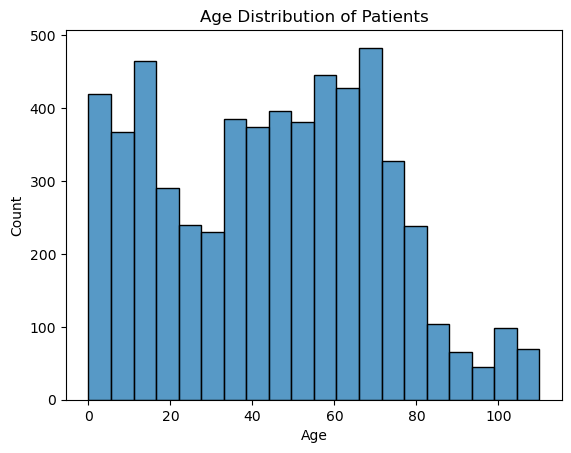

In [14]:
# Visualizations

import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(patients_df['AGE'], bins=20)
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

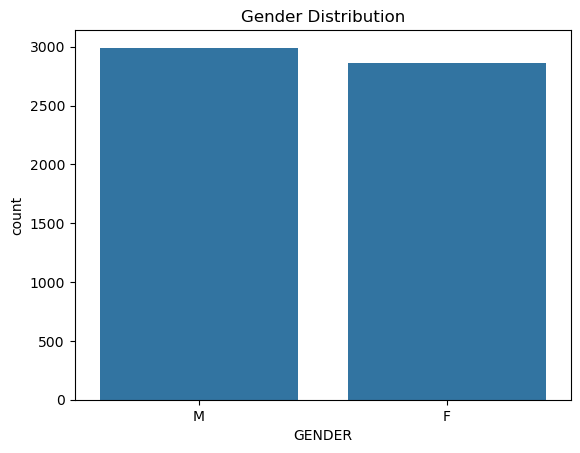

In [15]:
# Gender Distribution

sns.countplot(x='GENDER', data=patients_df)
plt.title('Gender Distribution')
plt.show()

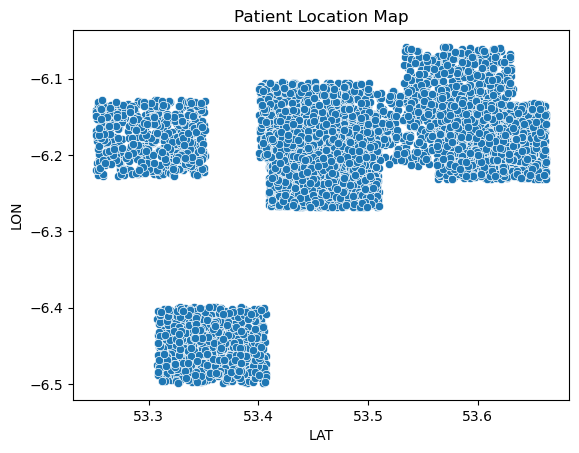

In [16]:
# Geographical Distribution
sns.scatterplot(x='LAT', y='LON', data=patients_df)
plt.title('Patient Location Map')
plt.show()

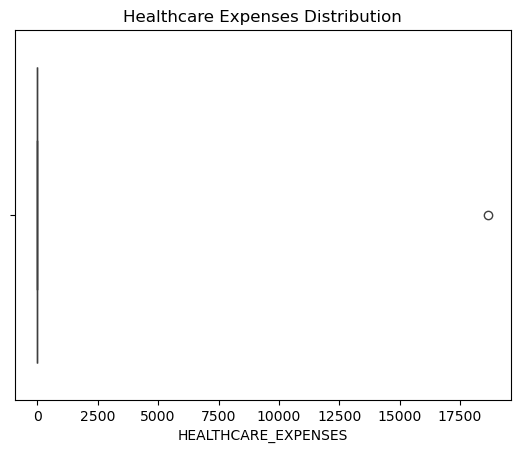

In [17]:
# Claims and Service Usage

sns.boxplot(x='HEALTHCARE_EXPENSES', data=patients_df)
plt.title('Healthcare Expenses Distribution')
plt.show()

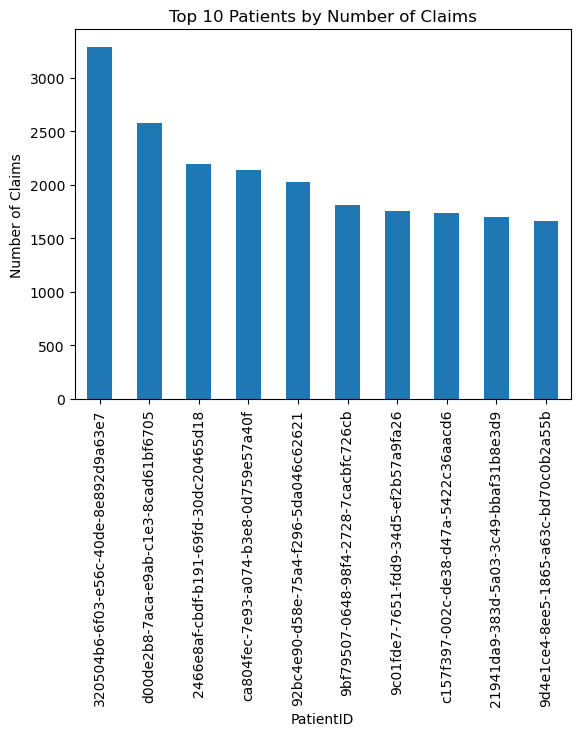

In [18]:
#Claims Analysis

import pandas as pd

# Total claims per patient
claims_per_patient = claims_df['PATIENTID'].value_counts()
top_patients = claims_per_patient.head(10)

# Plot top 10 patients with most claims
top_patients.plot(kind='bar')
plt.xlabel('PatientID')
plt.ylabel('Number of Claims')
plt.title('Top 10 Patients by Number of Claims')
plt.show()

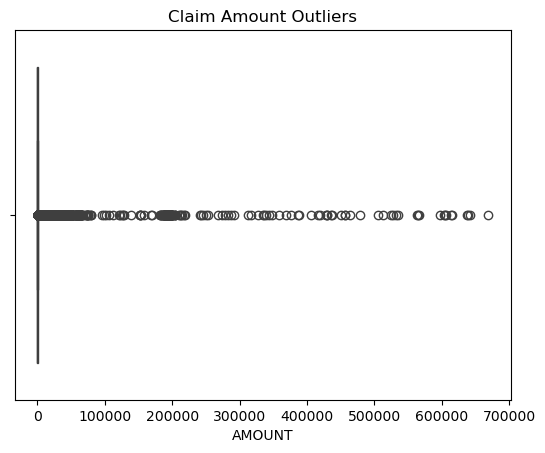

In [19]:
# ----------------------------------------------------
# |  Descriptive Statistics
# ----------------------------------------------------
# Summary of claim amounts per provider/member
# Distribution of claim frequencies per provider/member
# Identify outliers

# Example: Claim amount outliers
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=transactions_df['AMOUNT'])
plt.title('Claim Amount Outliers')
plt.show()

In [20]:
#Frequency and Pattern Analysis
#1. Count claims per provider, per patient, per diagnosis
#2. Detect unusually high claim counts or amounts

# Top providers by claim count
claims_per_provider = transactions_df['TRANS_PROVIDERID'].value_counts()
print(claims_per_provider.head(10))


TRANS_PROVIDERID
85c3cd9f-92ea-3271-87c3-1d111e212bff    557779
94c1a4ee-dbaa-3658-aa0e-7eeded94f0b2    305133
23cb0d98-cca9-3709-8b55-c0bbf530252e    294379
e723a516-488a-3882-acad-1eea38e74630    213847
f07f4af7-4e0a-3b57-91d9-cae2dbf6e639    192530
04792acd-43a3-3600-9241-55657298fc61     99749
dc411f83-874b-384b-965a-5809cae5542f     98815
c3134fb8-674b-3dd2-9d88-956cf3aafd55     87284
f9c77ae7-5c41-31ba-9367-6b28b861fa0c     77099
1a15e430-de3c-3952-85fc-fb10e10b759a     75137
Name: count, dtype: int64


In [21]:
# Anomoloy Detection 
# Use machine learning techniques such as Isolation Forest or Local Outlier Factor to find anomalous claims:
# 1. Prepare features (e.g., amount, units, claims count per provider/patient)
# 2. Encode categorical variables (provider, patient IDs)
# 3. Use IsolationForest or LocalOutlierFactor:
import sklearn
from sklearn.ensemble import IsolationForest # type: ignore
import numpy as np

# Example features
features = pd.DataFrame({
    'AMOUNT': merged_df['AMOUNT'],
    'UNITS': merged_df['UNITS'],
    # encode provider and patient IDs
    'PROVIDERID': merged_df['PROVIDERID'].astype('category').cat.codes,
    'PATIENTID': merged_df['PATIENTID'].astype('category').cat.codes
})

# Handling NaN
features.fillna(0, inplace=True)

# Fit IsolationForest
clf = IsolationForest(contamination=0.01, random_state=42)
merged_df['anomaly_score'] = clf.fit_predict(features)
suspect_claims = merged_df[merged_df['anomaly_score'] == -1]

In [22]:
# Define a high claim threshold, e.g., 99th percentile
high_claim_threshold = merged_df['AMOUNT'].quantile(0.99)
suspicious_claims = merged_df[merged_df['AMOUNT'] > high_claim_threshold]
print(suspicious_claims)

                                           Id  \
478      500a002a-4c4c-b67e-298a-0cf292de1d4e   
767      11099fba-855e-fec6-73bf-0e5504b31dd6   
1384     ee08ce4f-e3da-49d3-d1de-7fefd317769e   
1969     33dc5c0c-dee7-4ed6-c456-47c7d14a8e39   
2348     84a7545b-9ac1-41b5-af7b-e1d2baf70fe0   
...                                       ...   
3067695  5204eb0e-fd11-75bf-2463-1538b1b46af8   
3070516  80cf2a58-a064-89c3-8719-d60cdb4e0115   
3072284  f5239ecc-1355-d524-54a1-7546987b7fae   
3072294  3a2a64d7-e660-eba0-60ff-84ce47b03bc2   
3072451  f0522a1b-e06b-988e-3c63-d4680b5745dd   

                                    PATIENTID  \
478      96726661-b51d-2298-1ad0-e939f2e309c3   
767      55833c5a-53ed-e92c-3adf-4089a337bd91   
1384     5d023ddc-3888-eac5-09e4-3f84dc536d12   
1969     a0e288c2-c2b9-803e-b0a1-d7246ef6f5f6   
2348     0bb958bf-f20d-3061-04b7-73acd9804d1a   
...                                       ...   
3067695  4c8c24a4-cab6-278b-743f-6458088cfbe3   
3070516  4c8c24a4-c

# Visualizations for FWA

In [ ]:
# Visualizations for FWA
## 1. Histograms of claim amounts to see outliers
## 2. Heatmaps of claim frequencies across geography
## 3. Network graphs of providers and patients involved in suspicious claims


## 1. Histograms of claim amounts to see outliers

### Visualizing Claim Amount Distribution

This code creates a boxplot to visualize the distribution of claim amounts within the dataset. Using the `seaborn` library, the boxplot summarizes key statistical properties of the claim amounts, such as median, quartiles, and potential outliers.

**What the boxplot shows:**

- **Median (central line):** The middle value of claim amounts.
- **Interquartile Range (IQR):** The box spans from the 25th percentile (Q1) to the 75th percentile (Q3), representing the middle 50% of data.
- **Whiskers:** Lines extending from the box indicate the range of typical claim amounts, usually up to 1.5 times the IQR.
- **Outliers:** Points plotted outside the whiskers denote unusually high or low claim amounts, which could potentially be suspicious or erroneous.

**Purpose:**  
This visualization helps identify the typical claim size, detect outliers (e.g., abnormally high claims), and understand overall claim distribution, providing insights valuable for fraud detection and data quality assessments.

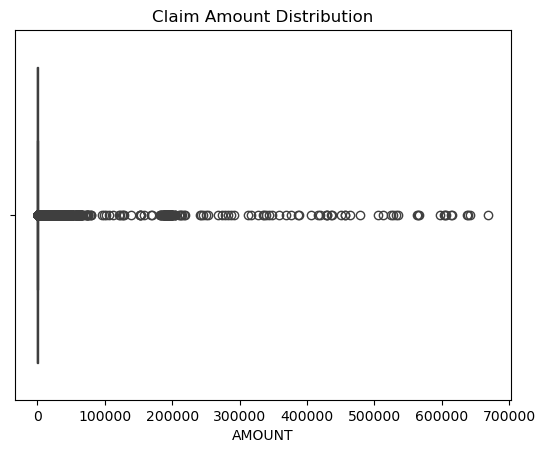

In [23]:
# Visualizations for FWA
# 1. Histograms of claim amounts to see outliers

import seaborn as sns
import matplotlib.pyplot as plt

# Plot claim amounts and claim frequency distributions:
sns.boxplot(x='AMOUNT', data=merged_df)
plt.title('Claim Amount Distribution')
plt.show()




## 2. Heatmaps of claim frequencies across geography

### Visualizing Claim Patterns: Geography and Time

#### 1. Heatmaps of Claim Frequencies Across Geography

*Note:* In the current code snippet, a heatmap of claim frequencies across geography can be created by aggregating claims based on location data such as latitude and longitude, and then visualizing this as a heatmap overlay on a map (e.g., using `folium`, `plotly`, or `seaborn`).

**What it represents:**  
This heatmap shows the distribution and density of claims across different geographic regions. Areas with higher claim frequencies may indicate hotspots that require further investigation, especially if they deviate from expected regional activity.

*Sample process:*  
- Aggregate claim counts by geographic units (e.g., ZIP code, latitude-longitude grid).  
- Visualize using a geographic heatmap, where warmer colors represent higher claim densities.

*(Note: The current code snippet does not include actual geographic plotting, but this is a common approach for spatial analysis.)*

---

#### 2. Claims Over Time

The histogram of claims over time provides insights into temporal patterns in claim submissions.

```python
merged_df['SERVICEDATE'].hist(bins=30)
plt.title('Claims Over Time')
plt.xlabel('Service Date')
plt.ylabel('Number of Claims')
plt.show()

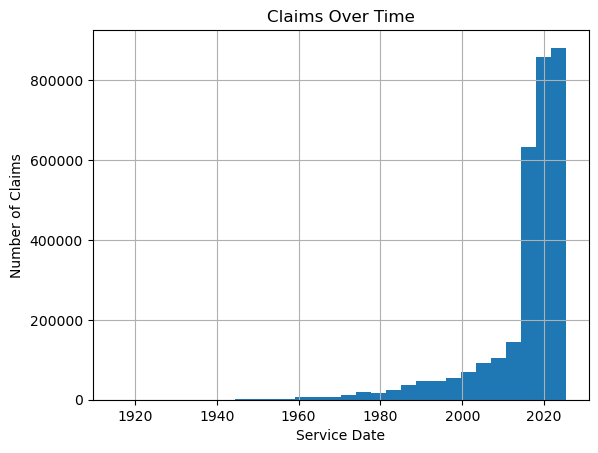

In [45]:
# Visualizations for FWA
# 2. Heatmaps of claim frequencies across geography
#---------------------------------------------------------------

# Claims over time
merged_df['SERVICEDATE'].hist(bins=30)
plt.title('Claims Over Time')
plt.xlabel('Service Date')
plt.ylabel('Number of Claims')
plt.show()

## Basic Provider-Patient Network Graph

### Introduction to the Provider-Patient Network Graph

This code constructs and visualizes a network graph to represent the relationships between healthcare providers and patients involved in suspicious claims. Using the `networkx` library, the graph illustrates how providers and patients are interconnected based on flagged (suspect) claims, enabling investigators to identify clusters or patterns that may indicate fraudulent or abusive activities.

**Key aspects:**

- **Nodes:**  
  - **Providers:** Represented in sky blue, these nodes indicate healthcare providers involved in suspicious claims.
  - **Patients:** Shown in light green, these nodes represent patients linked to suspicious activities.

- **Edges:**  
  - Connections between providers and patients depict the involvement in suspect claims.

**Purpose:**  
Visualizing these relationships helps identify suspicious clusters, central figures, or unusual interaction patterns that warrant further manual review or investigation. This approach transforms complex claim data into an intuitive visual format, facilitating targeted fraud detection efforts.

In [ ]:
# Visualizations for FWA
# 3. Network graphs of providers and patients involved in suspicious claims
#-------------------------------------------------------------------------------

import networkx as nx
import matplotlib.pyplot as plt

# Create a graph
G = nx.Graph()

# Add nodes and edges from suspect claims
for _, row in suspect_claims.iterrows():
    G.add_node(row['PROVIDERID'], type='provider')
    G.add_node(row['PATIENTID'], type='patient')
    G.add_edge(row['PROVIDERID'], row['PATIENTID'])

# Draw the graph with labels
pos = nx.spring_layout(G, seed=42)  # Layout for better visualization

# Color nodes based on type
node_colors = []
for node in G.nodes():
    if G.nodes[node]['type'] == 'provider':
        node_colors.append('skyblue')
    else:
        node_colors.append('lightgreen')

nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=500, font_size=8, alpha=0.8)

plt.title("Suspicious Provider-Patient Network")
plt.show()

## Interactive Provider-Patient Network Graph

### Interpretation of the Interactive Provider-Patient Network Graph

This network graph visually represents the suspicious interactions between healthcare providers and patients identified through our anomaly detection process.

**Key features of the graph:**

- **Nodes:**  
  - **Providers (skyblue nodes):** Each provider involved in suspicious claims is represented by a node labeled with their actual name. These are healthcare professionals or facilities suspected of irregular billing activities.
  - **Patients (lightgreen nodes):** Each patient involved in suspicious claims is represented by a node labeled with their actual name. These are individuals whose claims patterns raise suspicion.

- **Edges:**  
  - Each edge connects a provider and a patient, indicating that there is at least one claim linking them in the suspicious activity set. The pattern of connections can reveal clusters of providers and patients that are potentially involved in coordinated fraudulent or abusive practices.

---

### What does this graph tell us?

- **Clusters of suspicious interactions:**  
  Dense groups of interconnected providers and patients may indicate organized schemes or recurring suspicious activity.

- **Individual suspicious relationships:**  
  - Isolated edges highlight specific provider-patient pairs that warrant further manual review.

- **Network structure:**  
  The layout generated by the spring layout algorithm helps distribute nodes for clearer visualization, making it easier to identify central providers or patients involved in multiple suspicious claims.

---

### How to interpret the data?

- **Names and IDs:**  
  Hover over the nodes to see detailed information, including provider and patient names, IDs, and connection counts.

- **Colors:**  
  - **Skyblue nodes:** Providers involved in suspicious claims.  
  - **Lightgreen nodes:** Patients involved in suspicious claims.

---

### Importance in Fraud Detection

This visual tool aids investigators by:

- Offering an intuitive overview of complex interactions.
- Highlighting patterns that might be missed in tabular data.
- Focusing manual review efforts on high-risk clusters or specific provider-patient pairs.

---

### Summary

This network graph is a vital exploratory tool in our fraud detection pipeline, transforming raw claim data into an easy-to-understand visual representation, enabling more targeted and effective investigations into potential healthcare fraud, waste, and abuse.

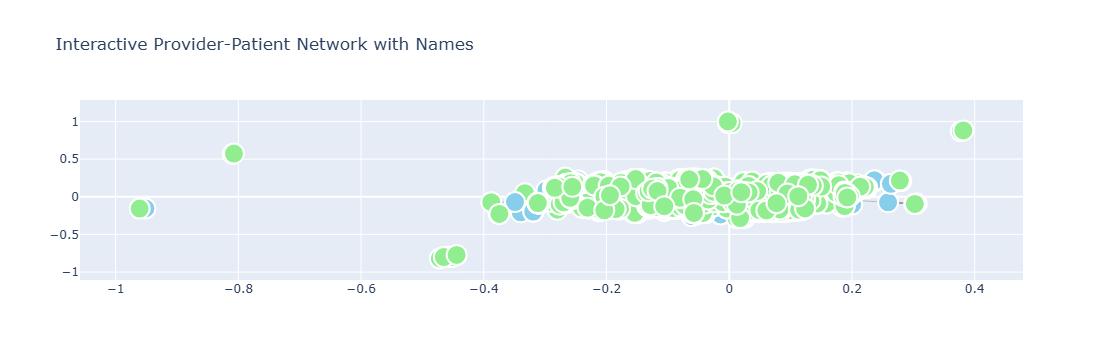

In [38]:
import networkx as nx
import pandas as pd
import plotly.graph_objects as go

# Assume your dataframes: patients_df, providers_df, and suspect_claims

# Create ID-to-Name dictionaries
patient_name_map = {
    row['Id']: f"{row['FIRST']} {row['LAST']}"
    for _, row in patients_df.iterrows()
}

provider_name_map = {
    row['Id']: row['NAME']
    for _, row in providers_df.iterrows()
}

G = nx.Graph()

# Add nodes with 'name' attribute
for _, row in suspect_claims.iterrows():
    prov_id = row['PROVIDERID']
    pat_id = row['PATIENTID']
    
    # Add provider node with name
    G.add_node(prov_id, type='provider', name=provider_name_map.get(prov_id, 'Provider Unknown'))
    # Add patient node with name
    G.add_node(pat_id, type='patient', name=patient_name_map.get(pat_id, 'Patient Unknown'))
    
    G.add_edge(prov_id, pat_id)

# Layout positions
pos = nx.spring_layout(G, seed=42)

# Prepare hover info with actual names
hover_texts = []
for node in G.nodes():
    data = G.nodes[node]
    name = data.get('name', 'Unknown')
    node_type = data.get('type', 'Unknown')
    count = len(list(G.neighbors(node)))
    hover_text = f"ID: {node}<br>Name: {name}<br>Type: {node_type}<br>Connections: {count}"
    hover_texts.append(hover_text)

# Map node attributes for plotly
node_x = []
node_y = []
node_colors = []

for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    node_type = G.nodes[node]['type']
    color = 'skyblue' if node_type == 'provider' else 'lightgreen'
    node_colors.append(color)

# Create plotly figure
fig = go.Figure()

# Edges
edge_x = []
edge_y = []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

fig.add_trace(go.Scatter(
    x=edge_x, y=edge_y,
    mode='lines',
    line=dict(width=0.5, color='#888'),
    hoverinfo='none'
))

# Nodes
fig.add_trace(go.Scatter(
    x=node_x,
    y=node_y,
    mode='markers',
    marker=dict(size=20, color=node_colors, line=dict(width=2, color='white')),
    text=hover_texts,
    hoverinfo='text'
))

fig.update_layout(title='Interactive Provider-Patient Network with Names', showlegend=False)
fig.show()